# Tier 1 — Reproduce the published figures

**What this needs:** the code (this repo) + the **Tier 1** data archive (`tier1_figuredata.zip`, ~48 MB). No MMseqs2, no BLAST/MAFFT, no corpus parsing.

**What it does:** re-renders every programmatic manuscript figure (Fig 2, Fig 3, and SI 1–6) from the cached numerical data in `FigureData/`, writing PDFs + PNGs into `Figures/`. This is the fast path for checking a result or tweaking a plot.

> Fig 1 is assembled by hand (external compositing of the ROC + tune sub-panels with hand-drawn illustrations) and is **not** regenerated here.

**Install once** (from the repo root): `pip install -e .`  
The setup cell below also works without installing, by adding `Src/` to the path.

In [1]:
import sys
from pathlib import Path


def find_repo_root(start=None):
    """Walk upward until we find the Src/thesession package."""
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "Src" / "thesession").is_dir():
            return cand
    raise RuntimeError("Could not locate the repo root (Src/thesession not found).")


REPO = find_repo_root()
if str(REPO / "Src") not in sys.path:
    sys.path.insert(0, str(REPO / "Src"))
print("Repo root:", REPO)


Repo root: /home/jmcbride/projects/TheSessionEvo


## 1. Make sure the Tier 1 data is present

On a fresh machine, download it first:

```bash
python scripts/download_data.py --tier figures
```

(Same command on Windows, macOS, Linux. Until the Zenodo record exists, unzip `Zenodo/tier1_figuredata.zip` at the repo root instead.)

In [2]:
def have(*rel_paths):
    """True if every path (relative to the repo root) exists."""
    return all((REPO / p).exists() for p in rel_paths)

tier1 = ["FigureData", "ProteinData/P00004",
         "Data/SavageFig/English.txt", "Cache/ParameterOptimizationSearch"]
if have(*tier1):
    print("Tier 1 data present \u2014 good to go.")
else:
    print("Tier 1 data NOT found. Run:  python scripts/download_data.py --tier figures")
    print("(or unzip Zenodo/tier1_figuredata.zip at the repo root)")

Tier 1 data present — good to go.


## 2. Render every figure

`make_figures()` reads only the `FigureData/` caches (plus a few small direct reads from `ProteinData/`, `Data/SavageFig/`, and `Cache/ParameterOptimizationSearch/`), so it runs in seconds.

In [3]:
import matplotlib
matplotlib.use("Agg")  # render to files; we display the PNGs below
import run_pipeline

run_pipeline.make_figures()
print("\nWrote figures to:", REPO / "Figures")

Fig 1 is assembled manually and is NOT regenerated by the pipeline.
  To rebuild its sub-panels: main_figs.plot_roc_curve() and, with a loaded
  `tunes` dict, main_figs.plot_example_tune(tunes).


/home/jmcbride/projects/TheSessionEvo/Src/thesession/analysis/substitution.py:705: RuntimeWarning: divide by zero encountered in log
  log_odds = np.log(prob) - np.log(exp_prob)


[1.85 1.49 1.32 1.34 1.31 1.23 1.15 1.09 1.05 1.07 1.07 1.03 1.  ]
Correlation with M-int distribution:
PearsonRResult(statistic=0.98400704466118, pvalue=1.3658256784621635e-09)
Correlation with M-int:
PearsonRResult(statistic=-0.7877738813967364, pvalue=0.0013848604656778415)
Linear fit:
-0.2007865989593683 0.7712693693513571 -0.823401025769883 0.0005423431118331784


/home/jmcbride/projects/TheSessionEvo/Src/thesession/analysis/substitution.py:705: RuntimeWarning: divide by zero encountered in log
  log_odds = np.log(prob) - np.log(exp_prob)
/home/jmcbride/projects/TheSessionEvo/Src/thesession/analysis/substitution.py:705: RuntimeWarning: invalid value encountered in subtract
  log_odds = np.log(prob) - np.log(exp_prob)
/home/jmcbride/projects/TheSessionEvo/Src/thesession/analysis/substitution.py:705: RuntimeWarning: divide by zero encountered in log
  log_odds = np.log(prob) - np.log(exp_prob)
/home/jmcbride/projects/TheSessionEvo/Src/thesession/analysis/substitution.py:705: RuntimeWarning: divide by zero encountered in log
  log_odds = np.log(prob) - np.log(exp_prob)



Wrote figures to: /home/jmcbride/projects/TheSessionEvo/Figures


## 3. Look at the results

The two main-text figures, inline. Every file written this run is listed underneath.

fig2


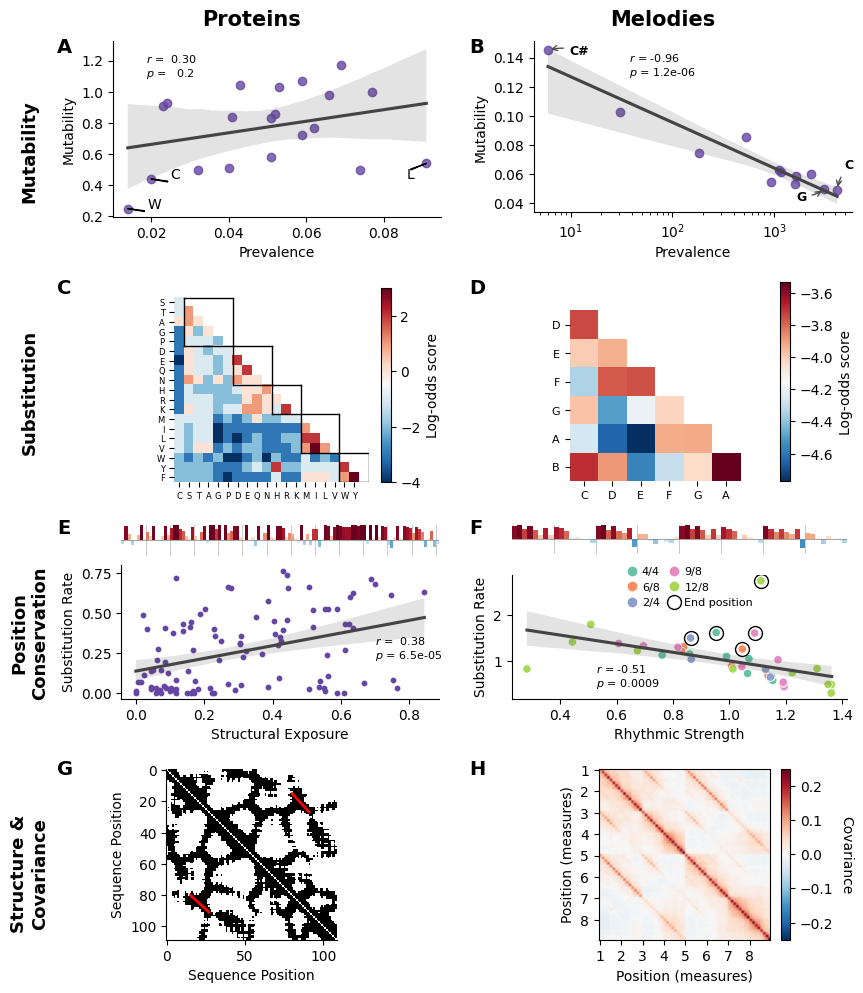

fig3


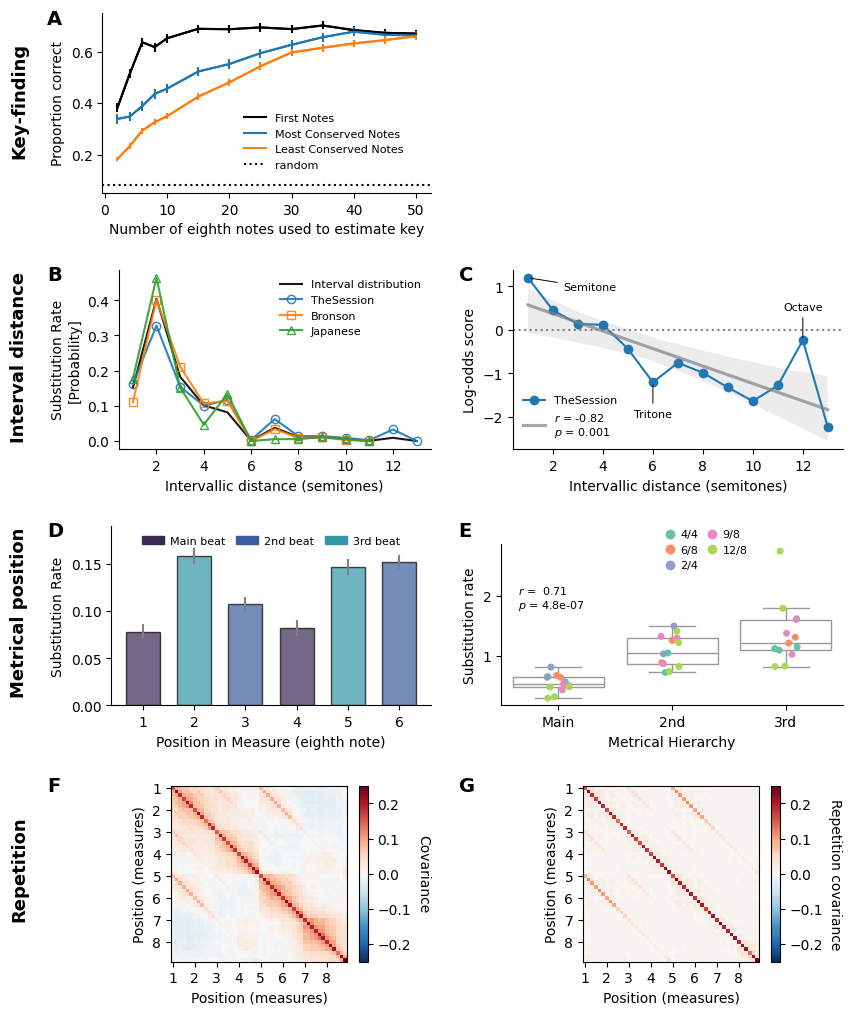

All figures written:
   fig1_roc.pdf
   fig1_tune.pdf
   fig2.pdf
   fig3.pdf
   fig4.pdf
   fig5.pdf
   si1_roc.pdf
   si2_mutability_by_mode.pdf
   si3_submat_comparison.pdf
   si3_submat_overall.pdf
   si4_submat_corr.pdf
   si5_bar_pos_sub_rate_meters_dances.pdf
   si6_cov_rep_all_meters.pdf


In [4]:
from IPython.display import Image, display

for name in ["fig2", "fig3"]:
    print(name)
    display(Image(filename=str(REPO / "Figures" / f"{name}.png")))

print("All figures written:")
for p in sorted((REPO / "Figures").glob("*.pdf")):
    print("  ", p.name)

## 4. Tweak a figure

Each figure is one function in `thesession.viz`. Call it directly to re-render just that one, and edit the function in `Src/thesession/viz/main_figs.py` (or `si_figs.py`) to change its appearance — all inputs are the cached arrays in `FigureData/`, so you never touch the alignment pipeline.

For example, `main_figs.fig3()` rebuilds `Figures/fig3.pdf` on its own:

[1.85 1.49 1.32 1.34 1.31 1.23 1.15 1.09 1.05 1.07 1.07 1.03 1.  ]
Correlation with M-int distribution:
PearsonRResult(statistic=0.98400704466118, pvalue=1.3658256784621635e-09)
Correlation with M-int:
PearsonRResult(statistic=-0.7877738813967364, pvalue=0.0013848604656778415)
Linear fit:
-0.2007865989593683 0.7712693693513571 -0.823401025769883 0.0005423431118331784


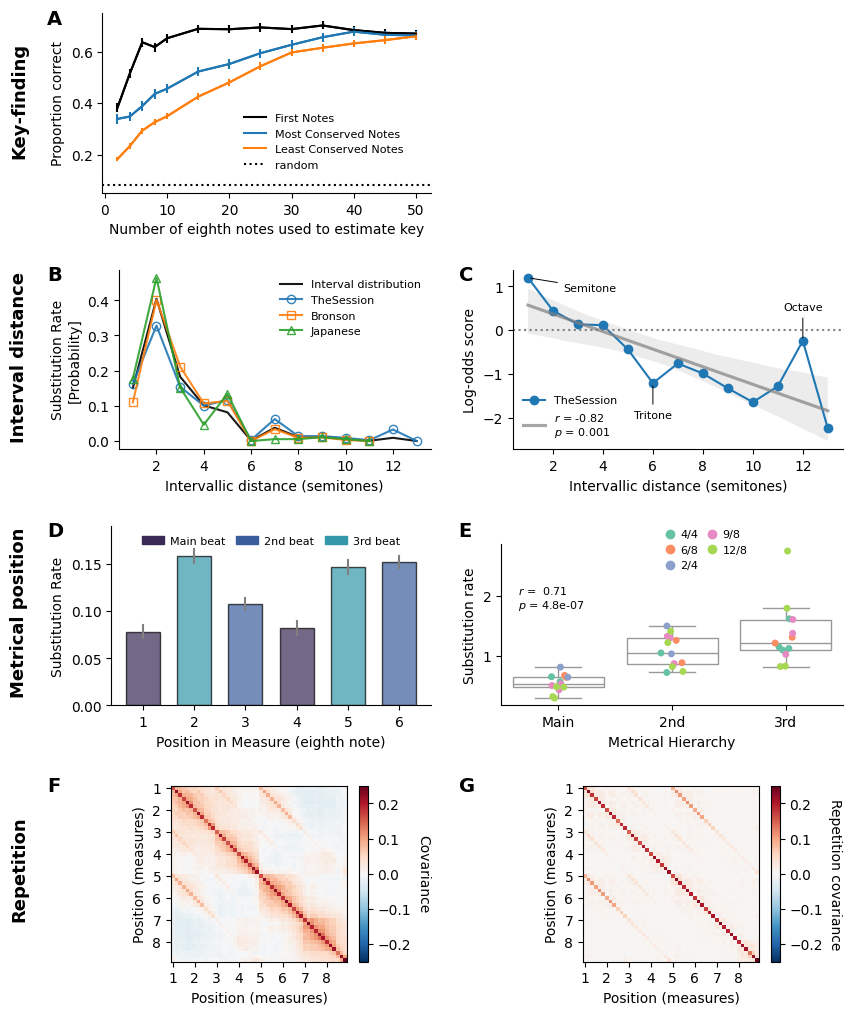

In [5]:
from thesession.viz import main_figs

main_figs.fig3()          # re-render just Figure 3
display(Image(filename=str(REPO / "Figures" / "fig3.png")))